In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

# Reading in data

In [2]:
#Raw Data

MCSLC_data = pd.read_excel("data/MCSLC.xlsx")
SPD_Calls_data = pd.read_excel("data/2015-2025 SPD Calls for Service.xlsx")
SPD_Responding_data = pd.read_excel("data/2015-2025 SPD Responding Units.xlsx")
SPD_Full = pd.read_excel("data/SPD_FULL.xlsx")

In [3]:
#CAD data

CAD_2015 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2015noloc.csv")
CAD_2016 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2016noloc.csv")
CAD_2017 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2017noloc.csv")
CAD_2018 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2018noloc.csv")
CAD_2019 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2019noloc.csv")
CAD_2020 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2020noloc.csv")
CAD_2021 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2021noloc.csv", low_memory=False)
CAD_2022 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2022noloc.csv")
CAD_2023 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2023noloc.csv")
CAD_2024 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2024noloc.csv")
CAD_2025 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2025noloc.csv", low_memory=False)


CAD_total = pd.concat([CAD_2015,
                       CAD_2016,
                       CAD_2017,
                       CAD_2018,
                       CAD_2019,
                       CAD_2020,
                       CAD_2021,
                       CAD_2022,
                       CAD_2023,
                       CAD_2024,
                       CAD_2025])

# CLEANING/PROCESSING STAGE

## simplifying dates

In [4]:
#date that CAHOOTS ceased operation in Eugene

CAHOOTS_closure = dt.datetime(2025, 4, 7)

In [5]:
#Create a simplified date column for Eugene CAD data.

CAD_total["Date"] = pd.to_datetime(CAD_total["calltime"]).dt.strftime("%Y-%m")
CAD_total["Date"] = pd.to_datetime(CAD_total["Date"], format = "%Y-%m")

CAD_total["Day"] = pd.to_datetime(CAD_total["calltime"]).dt.strftime("%Y-%m-%d")
CAD_total["Day"] = pd.to_datetime(CAD_total["Date"], format = "%Y-%m-%d")

CAD_total["CAHOOTS_closed"] = np.where(CAD_total["Day"] > CAHOOTS_closure, True, False)


In [6]:
#Creating simplified date column for MCSLC data.

MCSLC_data["Date"] = MCSLC_data["Dispatch Request Date & Time"].dt.strftime("%Y-%m")
MCSLC_data["Date"] = pd.to_datetime(MCSLC_data["Date"], format = "%Y-%m")

MCSLC_data["Day"] = MCSLC_data["Dispatch Request Date & Time"].dt.strftime("%Y-%m-%d")
MCSLC_data["Day"] = pd.to_datetime(MCSLC_data["Date"], format = "%Y-%m-%d")

MCSLC_data["CAHOOTS_closed"] = np.where(MCSLC_data["Day"] > CAHOOTS_closure, True, False)

In [7]:
#Creating simplified date column for SPD data.

SPD_Full["Date"] = SPD_Full["Call Creation Time"].dt.strftime("%Y-%m")
SPD_Full["Date"] = pd.to_datetime(SPD_Full["Date"], format = "%Y-%m")

SPD_Full["Day"] = SPD_Full["Call Creation Time"].dt.strftime("%Y-%m-%d")
SPD_Full["Day"] = pd.to_datetime(SPD_Full["Date"], format = "%Y-%m-%d")

SPD_Full["CAHOOTS_closed"] = np.where(SPD_Full["Day"] > CAHOOTS_closure, True, False)

## Subsetting MCSLC data by city

In [8]:
#Subsetting MCSLC data by City

MCSLC_Eugene = MCSLC_data[MCSLC_data["City"] == 'Eugene'].reset_index()
MCSLC_Springfield = MCSLC_data[MCSLC_data["City"] == 'Springfield'].reset_index()

## Subsetting Eugene and Springfield data by agency

In [9]:
#Known CAHOOTS unit codes

#Cahoots_codes1 = CAD_total[CAD_total["nature"] == "CHECK WELFARE, CAHOOTS"]["primeunit"].unique()
Cahoots_codes = np.array(['_CAHOT ', '_TESTCA', '_1J77  ', '_3J78  ', '_4J79  ', '_3J77  ', '_3J79  ',
                          '3J81  ', '3J76  ', '2J28  ', '2J29  ', 'CAHOOT  ', 'CAHOT  ', 'CAHO  '])

In [10]:
#Subsetting Eugene and Springfield call data by known CAHOOTS unit codes

CAHOOTS_EUG = CAD_total[CAD_total["primeunit"].isin(Cahoots_codes)].reset_index()
EPD = CAD_total[~CAD_total["primeunit"].isin(Cahoots_codes)].reset_index()

CAHOOTS_SPR = SPD_Full[SPD_Full["Primary Responding Unit"].isin(Cahoots_codes)].reset_index()
SPD = SPD_Full[~SPD_Full["Primary Responding Unit"].isin(Cahoots_codes)].reset_index()


## Identifying most common CAHOOTS/MCSLC call types

In [11]:
#Identifying most common CAHOOTS call types in Eugene

Top_Cahoots_natures_EUG = CAHOOTS_EUG.groupby('nature')["yr"].count().sort_values(ascending=False)
Top_Cahoots_natures_EUG[:25]

nature
ASSIST PUBLIC- POLICE           39540
CHECK WELFARE                   35105
TRANSPORT                       25035
PUBLIC ASSIST, CAHOOTS          19173
CHECK WELFARE, CAHOOTS          15793
SUICIDAL SUBJECT                 6132
TRANSPORT, CAHOOTS               4751
SUICIDAL SUBJECT, CAHOOTS        4344
INTOXICATED SUBJECT              2476
ASSIST PD, CAHOOTS               2175
INFO / ATL, CAHOOTS              1938
FOUND SYRINGE                    1860
DISORDERLY SUBJECT               1666
TRAFFIC HAZARD                   1654
ASSIST FIRE DEPARTMENT           1229
DISORDERLY SUBJECT, CAHOOTS      1184
TRAFFIC HAZARD, CAHOOTS          1053
DISORIENTED SUBJECT               727
ASSIST FD, CAHOOTS                681
INTOXICATED SUBJECT, CAHOOTS      657
CRIMINAL TRESPASS                 593
DISORIENTED SUBJECT, CAHOOTS      580
SUBJECT DOWN                      495
FOUND SYRINGE, CAHOOTS            473
CITIZEN CONTACT                   464
Name: yr, dtype: int64

In [12]:
#Identifying most common CAHOOTS call types in Springfield

Top_Cahoots_natures_SPR = CAHOOTS_SPR.groupby("Final Call Type")['Incident Number'].count().sort_values(ascending=False)

Top_Cahoots_natures_SPR[:10]

Final Call Type
CHECK WELFARE             18126
ASSIST PUBLIC- POLICE     16656
SUICIDAL SUBJECT           1975
INTOXICATED SUBJECT        1161
DISORDERLY SUBJECT          662
FOUND SYRINGE               619
TRANSPORT                   544
CRIMINAL TRESPASS           405
TRAFFIC HAZARD              357
ASSIST FIRE DEPARTMENT      345
Name: Incident Number, dtype: int64

In [13]:
#Identifying most common MCSLC call types

Top_MCSLC_natures = MCSLC_data.groupby("Reason for Dispatch #1")["ID"].count().sort_values(ascending=False)
Top_MCSLC_natures[:10]

Reason for Dispatch #1
Agitation or disruptive behavior             1492
Suicidality or suicide attempt                681
Disorganized behavior                         654
Needing social/mental health services         528
Difficulty functioning                        409
Harm/risk of harm to self/others/property     330
Paranoia                                      116
Substance use                                 115
Adult Social/interpersonal problems           114
Other                                          50
Name: ID, dtype: int64

## Limiting EPD/SPD call types to CAHOOTS related calls

## Subsetting by call type

In [14]:
#EPD/SPD Welfare Checks
EPD_welfare = EPD[EPD["nature"] == "CHECK WELFARE"]
SPD_welfare = SPD[SPD["Final Call Type"] == "CHECK WELFARE"]

#EPD/SPD Suicidal Subjects
EPD_Suicidal = EPD[EPD["nature"] == "SUICIDAL SUBJECT"]
SPD_Suicidal = SPD[SPD["Final Call Type"] == "SUICIDAL SUBJECT"]

## Creating call volume dataframes

In [15]:
#Monthly call volume data frames for CAHOOTS, EPD, and SPD data

CAHOOTS_EUG_VOLUME = CAHOOTS_EUG.groupby("Date")["inci_id"].count().reset_index().rename(columns = {"inci_id": "CH_EUG_CALLS"})
CAHOOTS_EUG_VOLUME = CAHOOTS_EUG_VOLUME.rename(columns = {"inci_id": "CH_EUG_CALLS"})

CAHOOTS_SPR_VOLUME = CAHOOTS_SPR.groupby("Date")["Incident Number"].count().reset_index()
CAHOOTS_SPR_VOLUME = CAHOOTS_SPR_VOLUME.rename(columns = {"Incident Number": "CH_SPR_CALLS"})

EPD_VOLUME = EPD.groupby("Date")["inci_id"].count().reset_index()
EPD_VOLUME = EPD_VOLUME.rename(columns = {"inci_id": "EPD_CALLS"})

SPD_VOLUME = SPD.groupby("Date")["Incident Number"].count().reset_index()
SPD_VOLUME = SPD_VOLUME.rename(columns = {"Incident Number": "SPD_CALLS"})

#Monthly call volume data frame for MCSLSC
MCSLC_EUG_VOLUME = MCSLC_Eugene.groupby("Date")["ID"].count().reset_index()
MCSLC_EUG_VOLUME = MCSLC_EUG_VOLUME.rename(columns = {"ID": "MCSLC_EUG_CALLS"})

MCSLC_SPR_VOLUME = MCSLC_Springfield.groupby("Date")["ID"].count().reset_index()
MCSLC_SPR_VOLUME = MCSLC_SPR_VOLUME.rename(columns = {"ID": "MCSLC_SPR_CALLS"})

#Total Eugene call volumes
TOTAL_EUG_VOLUME = EPD_VOLUME.merge(CAHOOTS_EUG_VOLUME, how = "left", on = "Date")
TOTAL_EUG_VOLUME = TOTAL_EUG_VOLUME.merge(MCSLC_EUG_VOLUME, how = "left", on = "Date")
TOTAL_EUG_VOLUME = TOTAL_EUG_VOLUME.fillna(0)

#Total Springfield call volumes
TOTAL_SPR_VOLUME = SPD_VOLUME.merge(CAHOOTS_SPR_VOLUME, on = "Date")
TOTAL_SPR_VOLUME = TOTAL_SPR_VOLUME.merge(MCSLC_SPR_VOLUME, how = "left", on = "Date")
TOTAL_SPR_VOLUME = TOTAL_SPR_VOLUME.fillna(0)

## Calculating call proportions by agency

In [16]:
#Eugene call proportions
TOTAL_EUG_VOLUME["PROP_EPD"] = TOTAL_EUG_VOLUME["EPD_CALLS"] / (TOTAL_EUG_VOLUME["EPD_CALLS"] + TOTAL_EUG_VOLUME["CH_EUG_CALLS"] + TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"])
TOTAL_EUG_VOLUME["PROP_CAHOOTS"] = TOTAL_EUG_VOLUME["CH_EUG_CALLS"] / (TOTAL_EUG_VOLUME["EPD_CALLS"] + TOTAL_EUG_VOLUME["CH_EUG_CALLS"] + TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"])
TOTAL_EUG_VOLUME["PROP_MCSLC"] = TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"] / (TOTAL_EUG_VOLUME["EPD_CALLS"] + TOTAL_EUG_VOLUME["CH_EUG_CALLS"] + TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"])

#Spriungfield call proportions
TOTAL_SPR_VOLUME["PROP_SPD"] = TOTAL_SPR_VOLUME["SPD_CALLS"] / (TOTAL_SPR_VOLUME["SPD_CALLS"] + TOTAL_SPR_VOLUME["CH_SPR_CALLS"] + TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"])
TOTAL_SPR_VOLUME["PROP_CAHOOTS"] = TOTAL_SPR_VOLUME["CH_SPR_CALLS"] / (TOTAL_SPR_VOLUME["SPD_CALLS"] + TOTAL_SPR_VOLUME["CH_SPR_CALLS"] + TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"])
TOTAL_SPR_VOLUME["PROP_MCSLC"] = TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"] / (TOTAL_SPR_VOLUME["SPD_CALLS"] + TOTAL_SPR_VOLUME["CH_SPR_CALLS"] + TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"])

# Initial Vizualizations

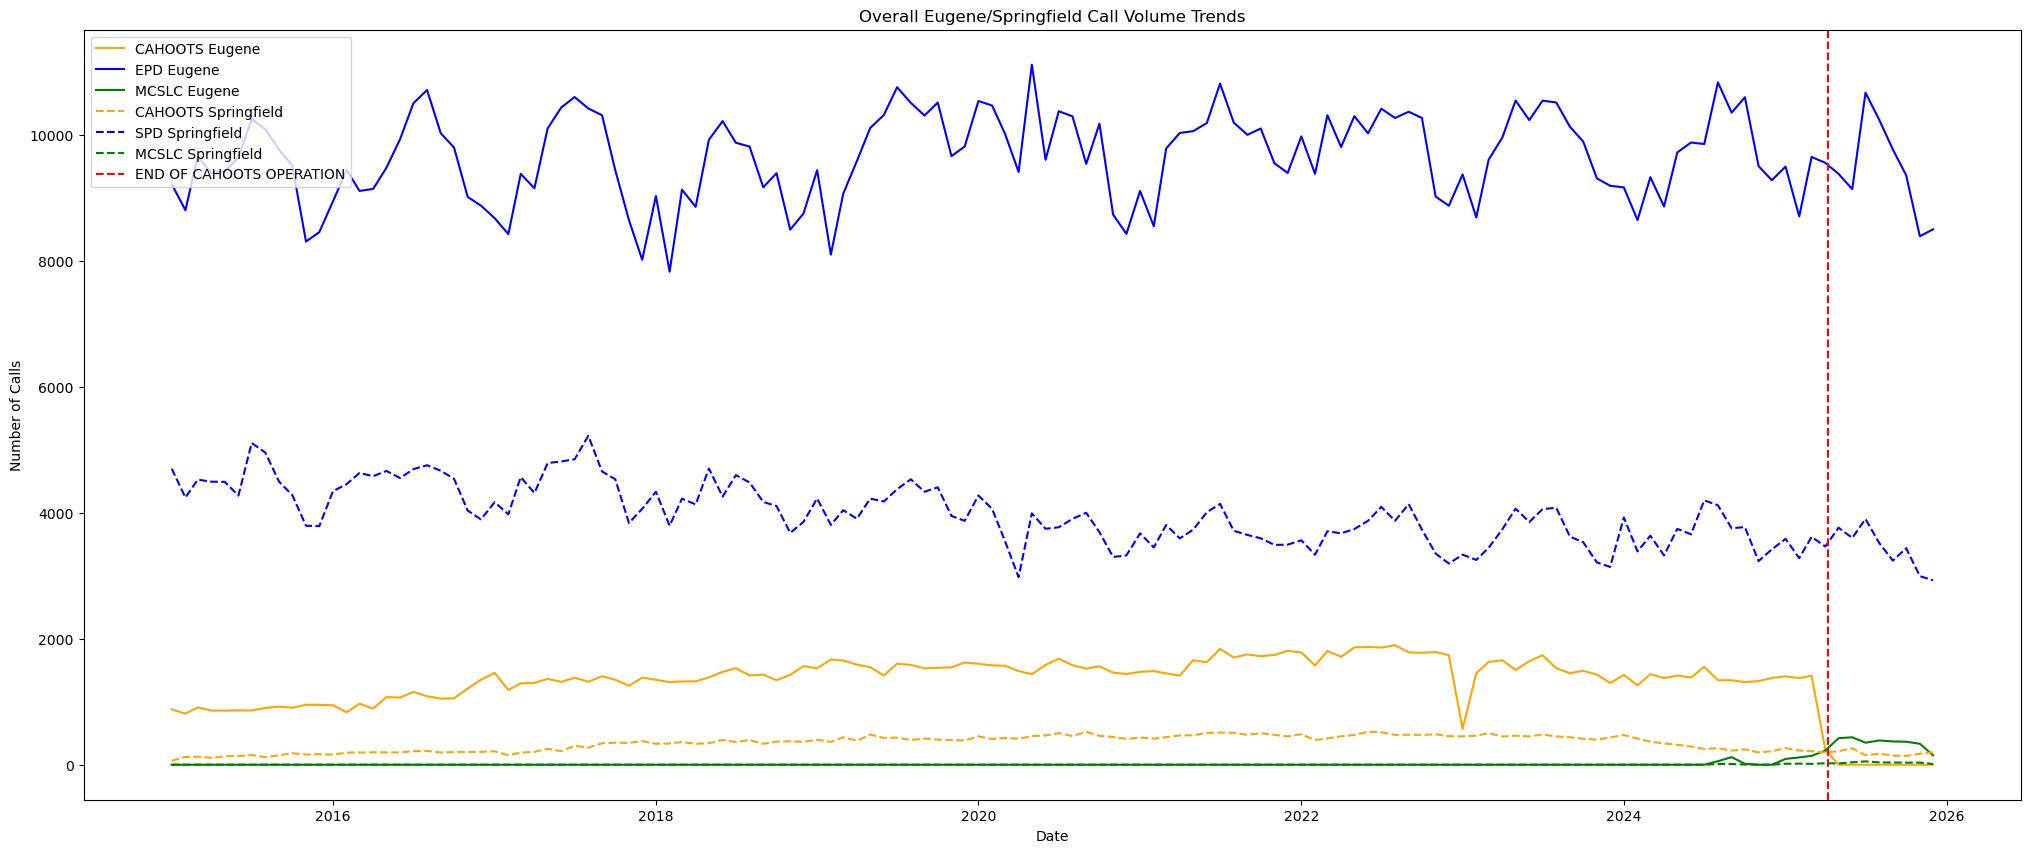

In [17]:
#ALL CALL VOLUME DATA

plt.figure(figsize=(25,10))

#Eugene Data
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "CH_EUG_CALLS", label = "CAHOOTS Eugene", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "EPD_CALLS", label = "EPD Eugene", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "MCSLC_EUG_CALLS", label = "MCSLC Eugene", color = "green")

#Springfield Data
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "CH_SPR_CALLS", label = "CAHOOTS Springfield", linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "SPD_CALLS", label = "SPD Springfield", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "MCSLC_SPR_CALLS", label = "MCSLC Springfield", linestyle = "--", color = "green")

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Overall Eugene/Springfield Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.legend(loc = "upper left")

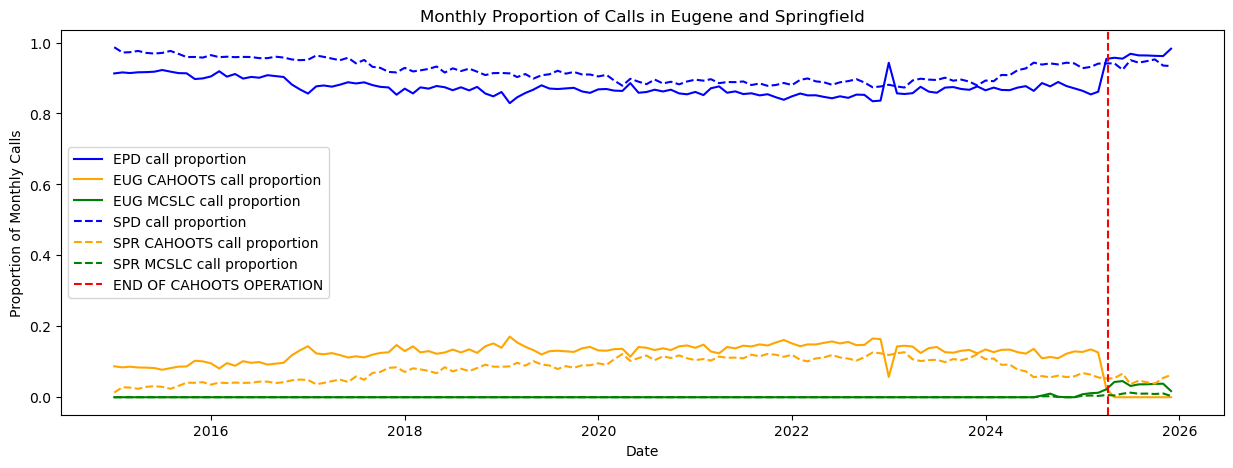

In [18]:
#OVERALL CALL PROPORTIONS

plt.figure(figsize=(15,5))

#Eugene
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_EPD", label = "EPD call proportion", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_CAHOOTS", label = "EUG CAHOOTS call proportion", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_MCSLC", label = "EUG MCSLC call proportion", color = 'green')


#Springfield
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_SPD", label = "SPD call proportion", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_CAHOOTS", label = "SPR CAHOOTS call proportion",linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_MCSLC", label = "SPR MCSLC call proportion", linestyle = "--", color = 'green')

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Monthly Proportion of Calls in Eugene and Springfield")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
plt.legend()

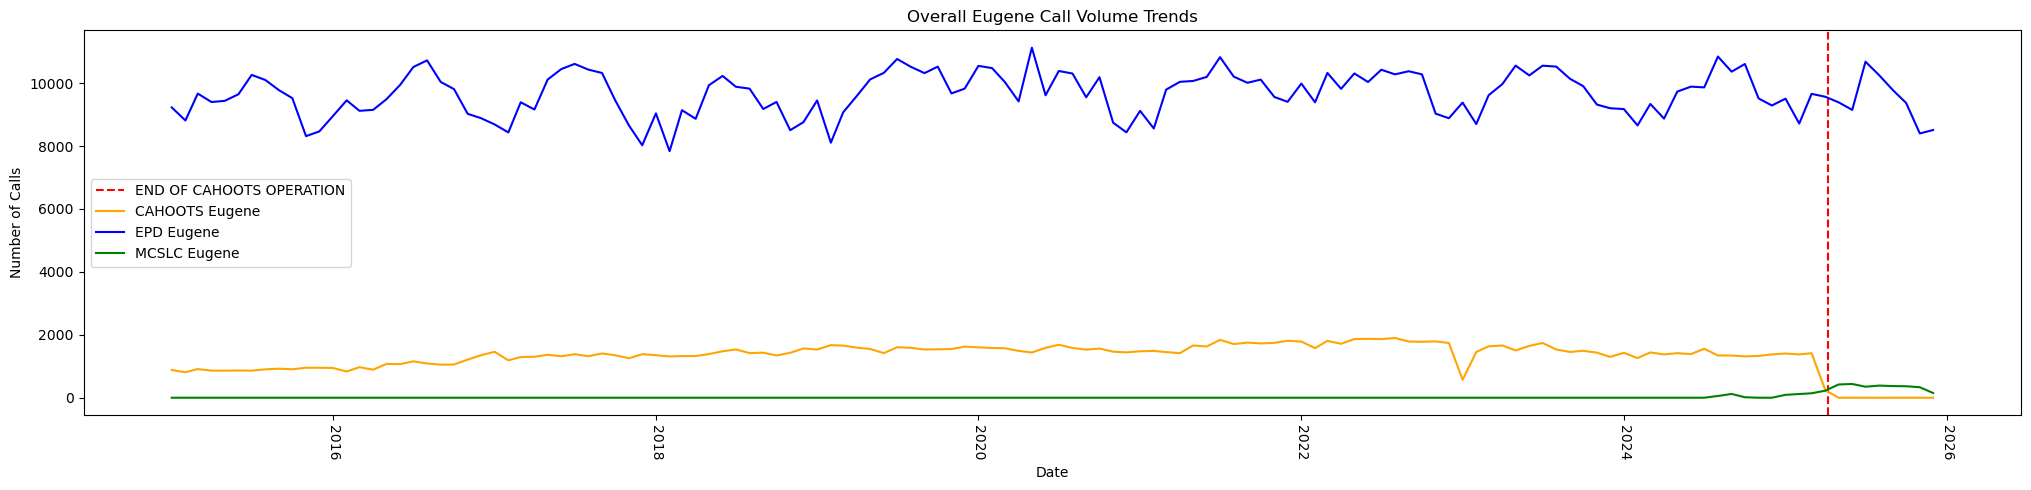

In [19]:
#Overall Eugene Call Volume Trends

plt.figure(figsize=(25,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "CH_EUG_CALLS", label = "CAHOOTS Eugene", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "EPD_CALLS", label = "EPD Eugene", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "MCSLC_EUG_CALLS", label = "MCSLC Eugene", color = "green")
plt.title("Overall Eugene Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation = -90);

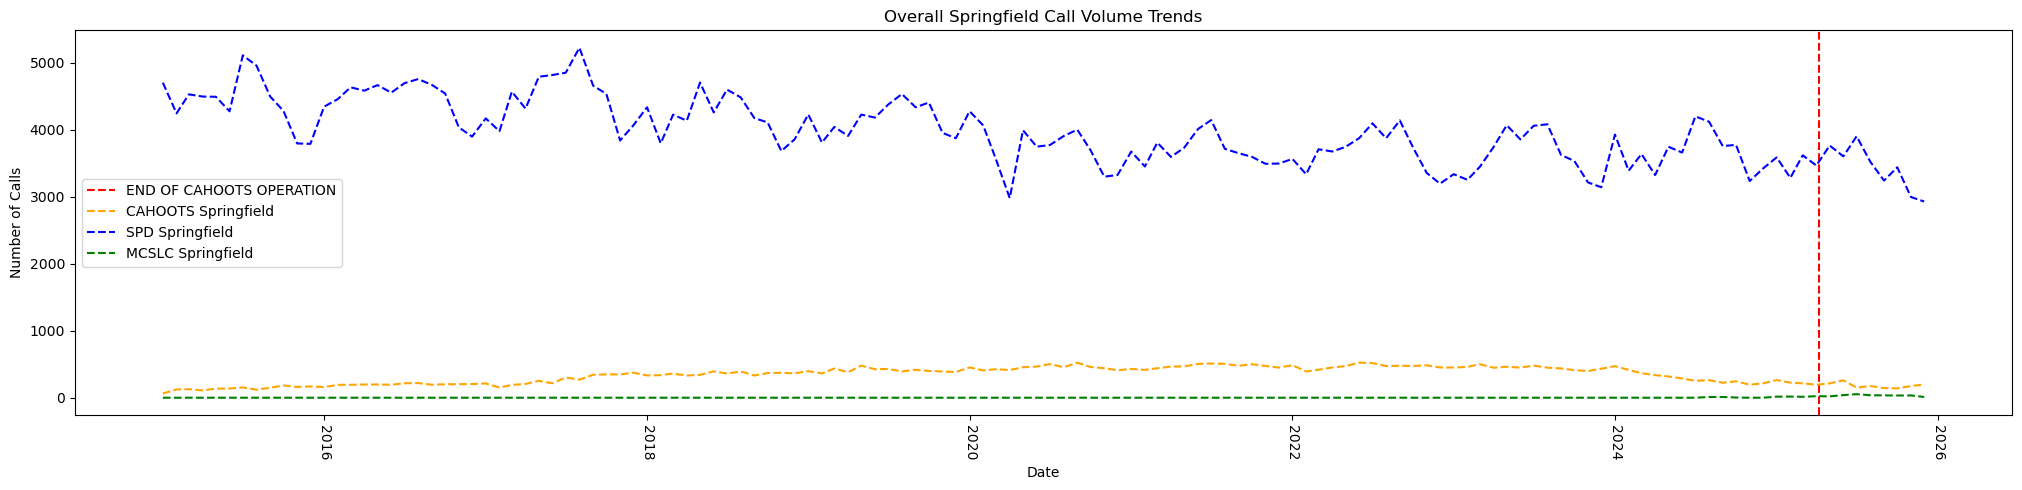

In [20]:
#Overall Springfield Call Volume Trends

plt.figure(figsize=(25,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "CH_SPR_CALLS", label = "CAHOOTS Springfield", linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "SPD_CALLS", label = "SPD Springfield", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "MCSLC_SPR_CALLS", label = "MCSLC Springfield", linestyle = "--", color = "green")
plt.title("Overall Springfield Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation = -90);

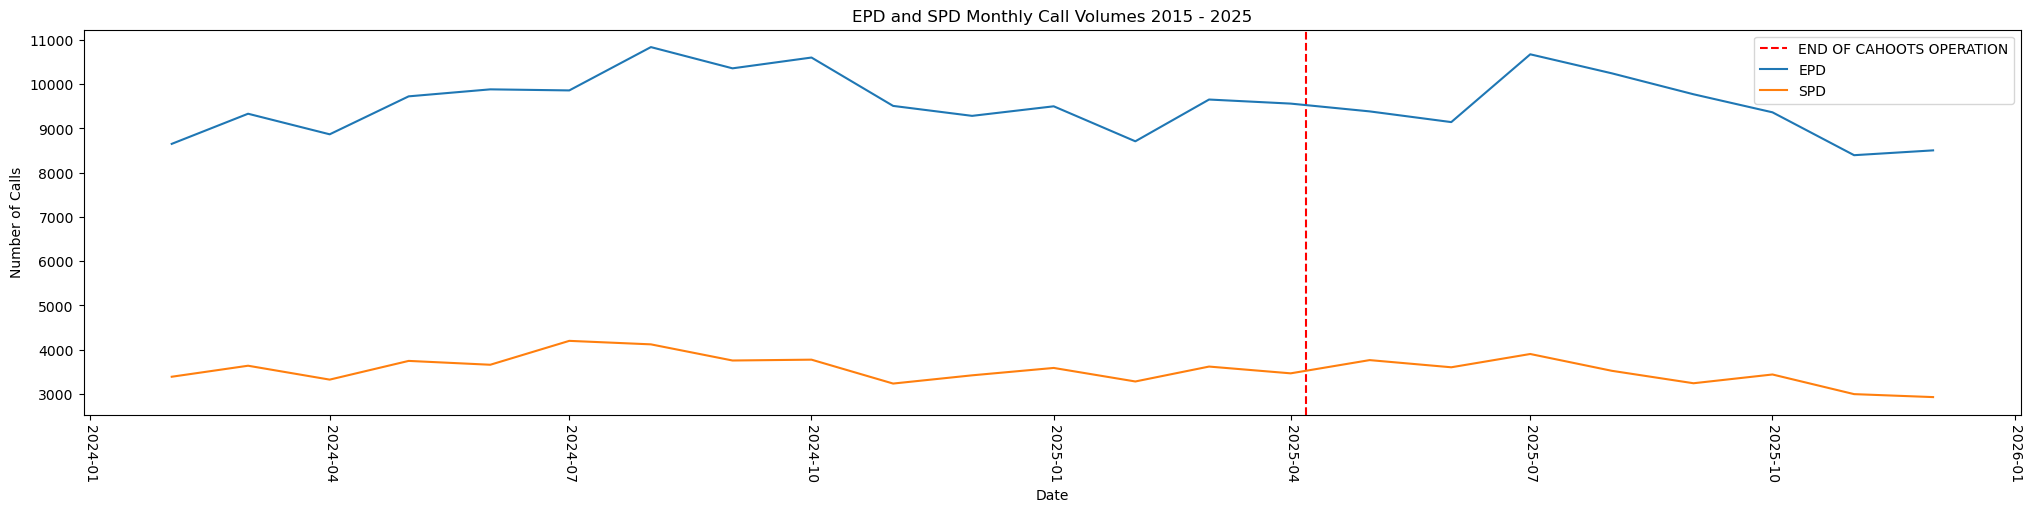

In [21]:
#EPD vs SPD trends

plt.figure(figsize=(25,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "EPD_CALLS", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "SPD_CALLS", label = "SPD")

plt.title("EPD and SPD Monthly Call Volumes 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation = -90);

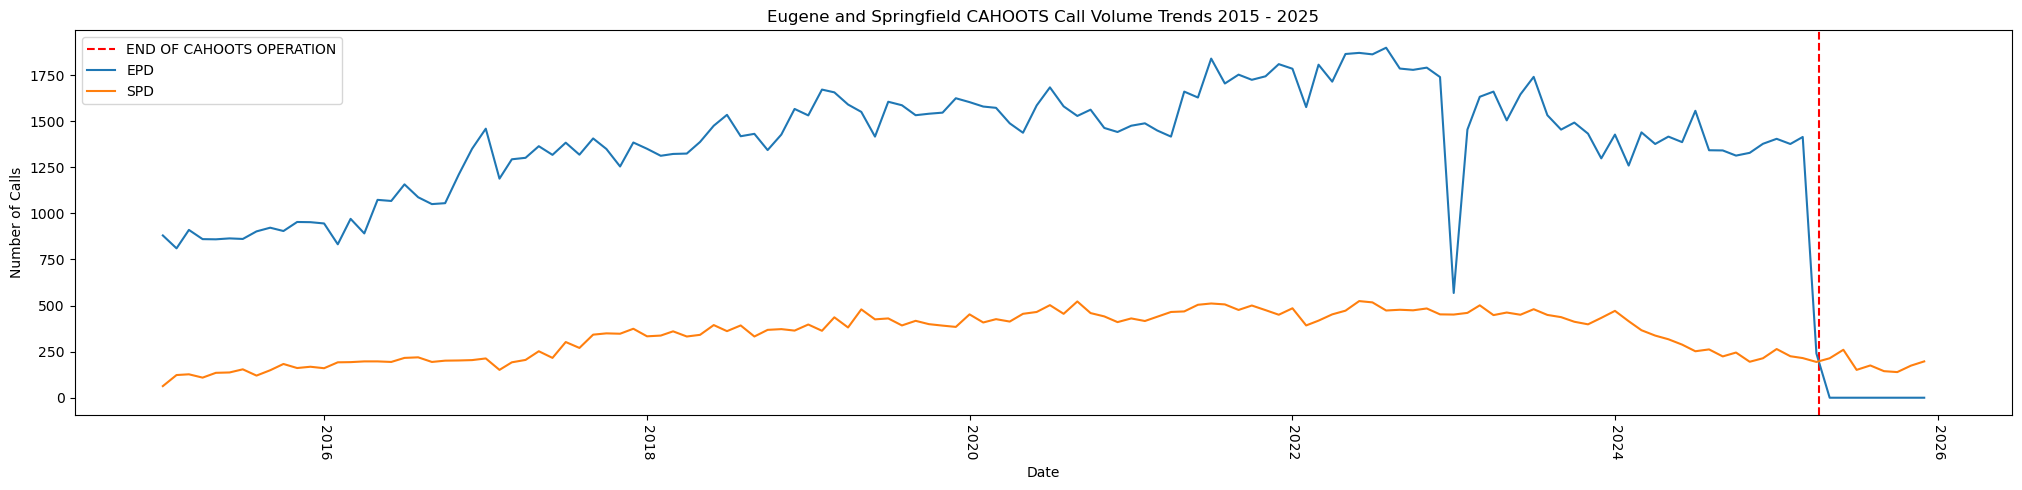

In [22]:
#Eugene vs Springfield CAHOOTS Call Volume Trends

plt.figure(figsize=(25,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "CH_EUG_CALLS", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "CH_SPR_CALLS", label = "SPD")

plt.title("Eugene and Springfield CAHOOTS Call Volume Trends 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=-90);

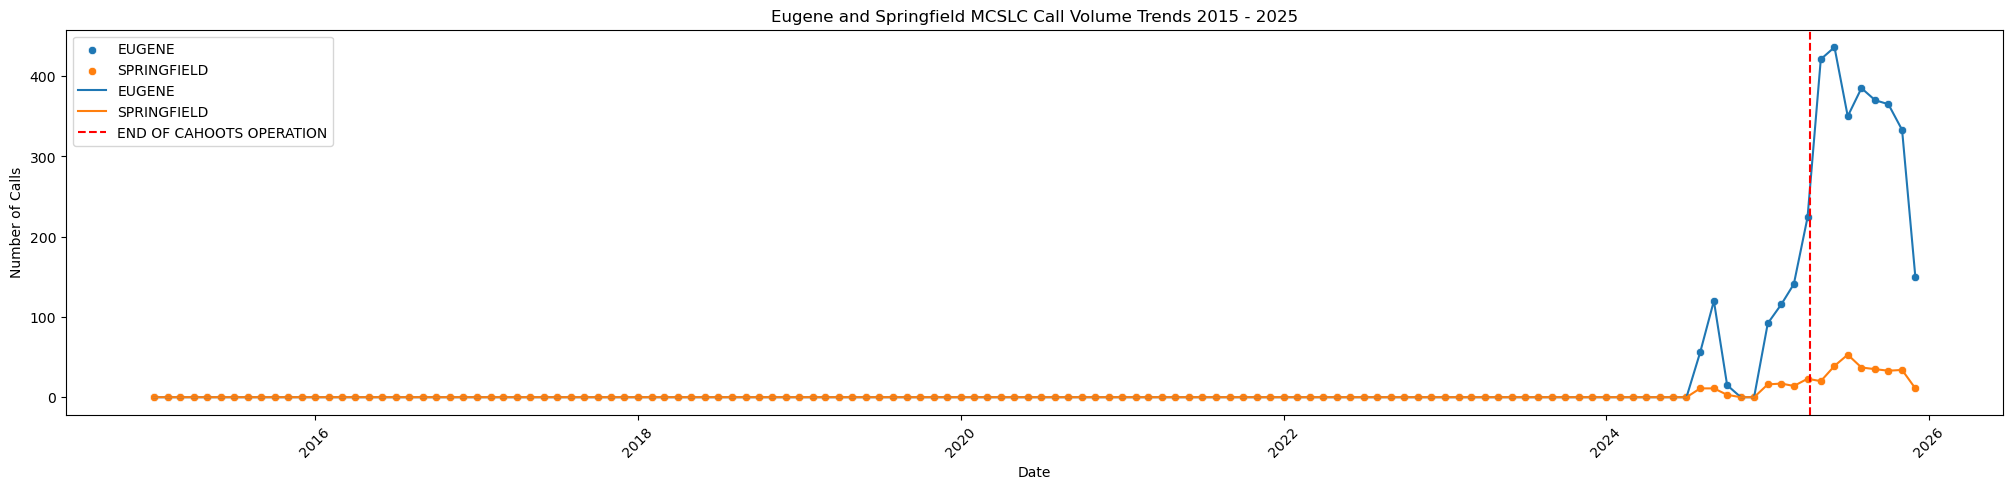

In [23]:
#Eugene vs Springfield MCSLC Call Volume Trends
plt.figure(figsize=(25,5))

sns.scatterplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "MCSLC_EUG_CALLS", label = "EUGENE")
sns.scatterplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "MCSLC_SPR_CALLS", label = "SPRINGFIELD")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "MCSLC_EUG_CALLS", label = "EUGENE")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "MCSLC_SPR_CALLS", label = "SPRINGFIELD")

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")



plt.title("Eugene and Springfield MCSLC Call Volume Trends 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.legend()
plt.xticks(rotation=45);

# Call type Specific visualizations

In [24]:
EPD_Welfare_Volume = EPD_welfare.groupby("Date")["inci_id"].count().reset_index()
SPD_Welfare_Volume = SPD_welfare.groupby("Date")["Incident Number"].count().reset_index()

EPD_Suicidal_Volume = EPD_Suicidal.groupby("Date")["inci_id"].count().reset_index()
SPD_Suicidal_Volume = SPD_Suicidal.groupby("Date")["Incident Number"].count().reset_index()

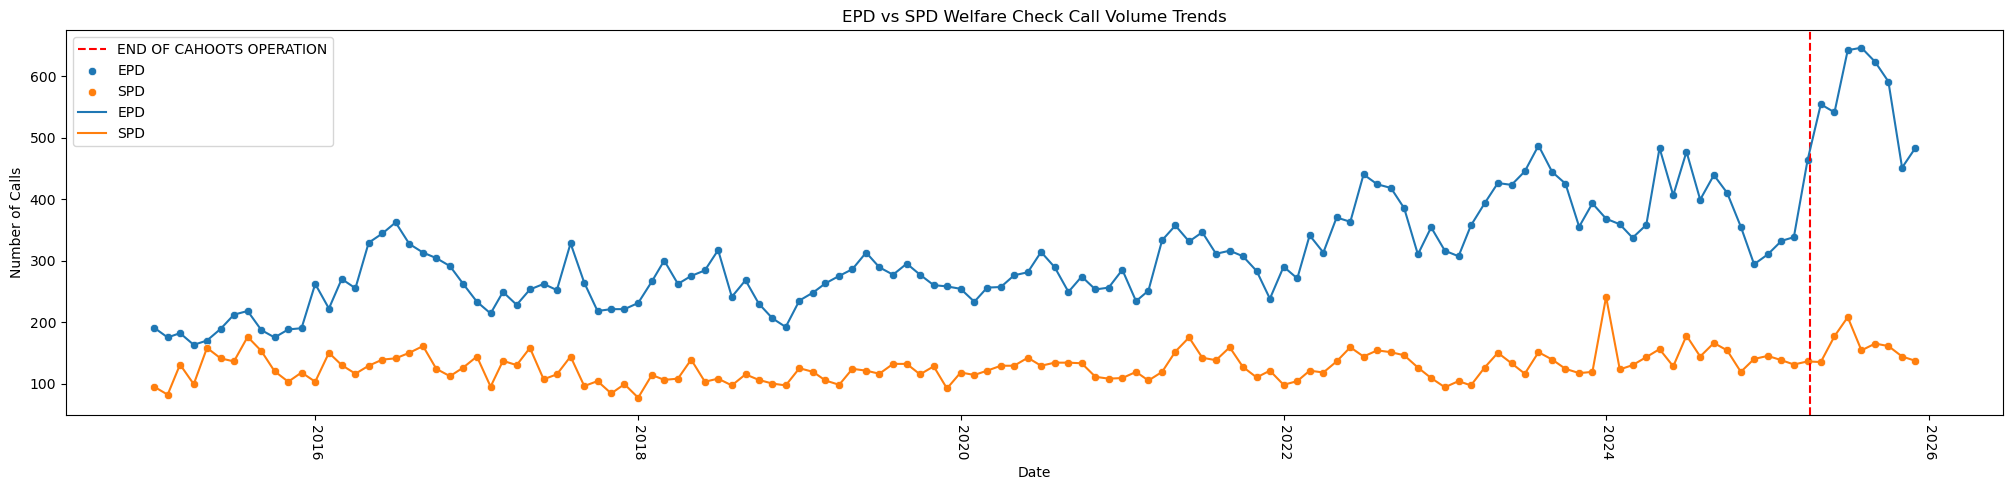

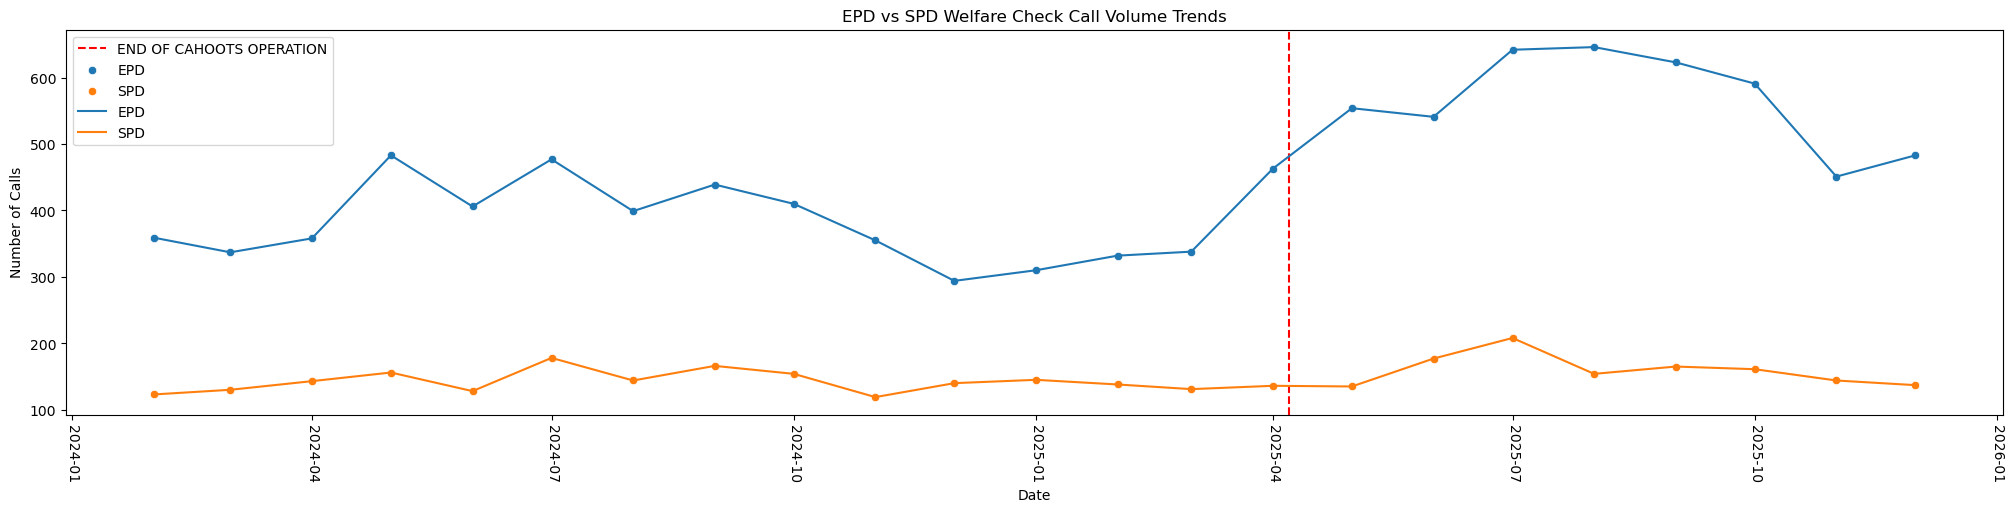

In [25]:
#EPD vs SPD Welfare checks

#FULL
plt.figure(figsize=(25,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = EPD_Welfare_Volume, x = "Date", y = "inci_id", label = "EPD")
sns.scatterplot(data = SPD_Welfare_Volume, x = "Date", y = "Incident Number", label = "SPD")

sns.lineplot(data = EPD_Welfare_Volume, x = "Date", y = "inci_id", label = "EPD")
sns.lineplot(data = SPD_Welfare_Volume, x = "Date", y = "Incident Number", label = "SPD")

plt.title("EPD vs SPD Welfare Check Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=-90);


#2024 - 2025
plt.figure(figsize=(25,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = EPD_Welfare_Volume[EPD_Welfare_Volume["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "inci_id", label = "EPD")
sns.scatterplot(data = SPD_Welfare_Volume[SPD_Welfare_Volume["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "Incident Number", label = "SPD")

sns.lineplot(data = EPD_Welfare_Volume[EPD_Welfare_Volume["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "inci_id", label = "EPD")
sns.lineplot(data = SPD_Welfare_Volume[SPD_Welfare_Volume["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "Incident Number", label = "SPD")

plt.title("EPD vs SPD Welfare Check Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=-90);

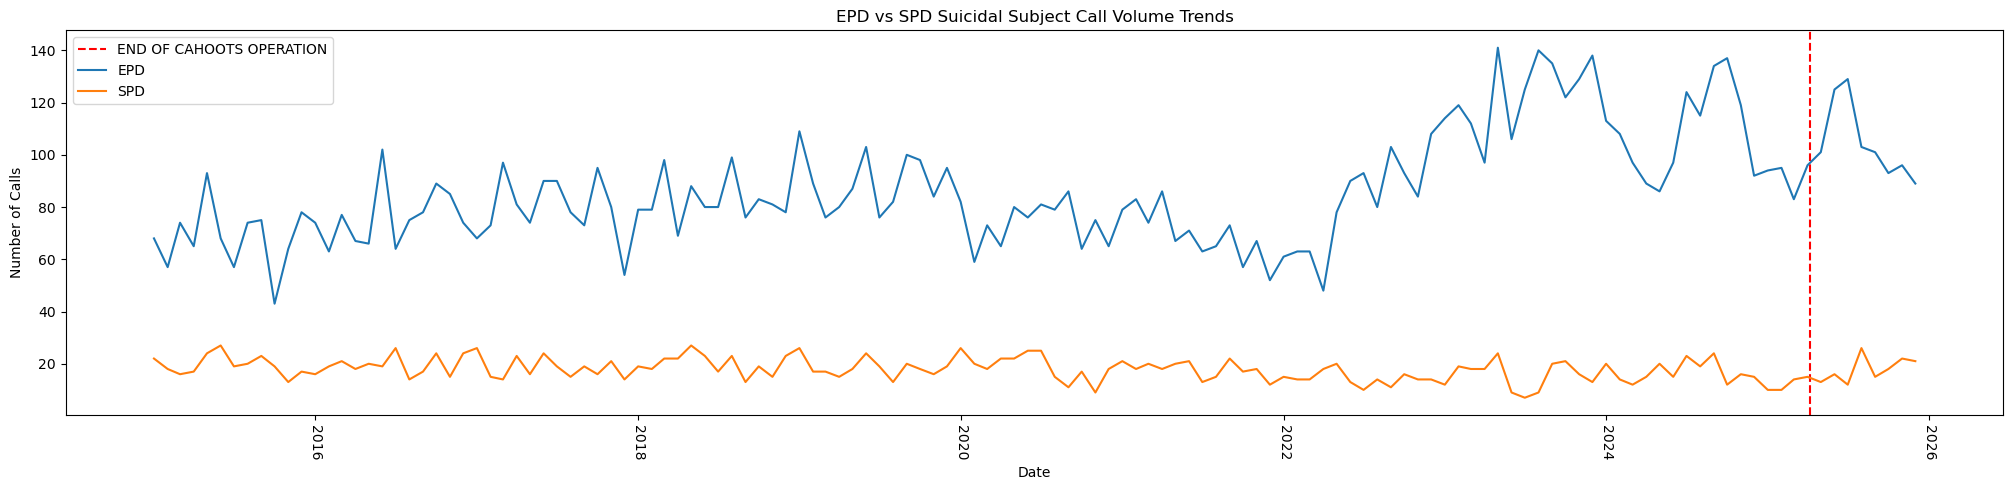

In [26]:
#EPD vs SPD Suicidal Subject

plt.figure(figsize=(25,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = EPD_Suicidal_Volume, x = "Date", y = "inci_id", label = "EPD")
sns.lineplot(data = SPD_Suicidal_Volume, x = "Date", y = "Incident Number", label = "SPD")

plt.title("EPD vs SPD Suicidal Subject Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=-90);